In [16]:
import numpy as np
from gpcam import GPOptimizer

import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt

import plotly.graph_objects as go

import os

#import time


# Creating the function

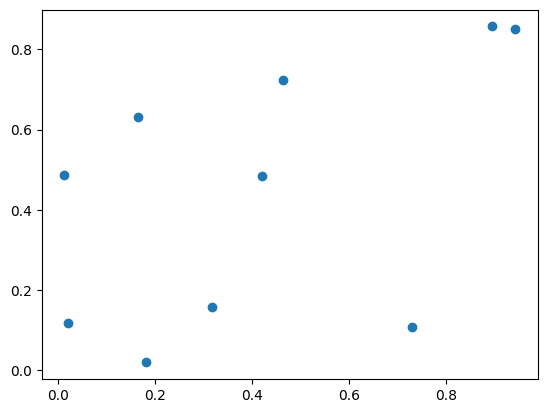

In [17]:
x_min,x_max = 0, 1

np.random.seed(11)  # Use any integer you like

x_train = np.random.rand(10,2)


plt.scatter(x_train[:,0],x_train[:,1])

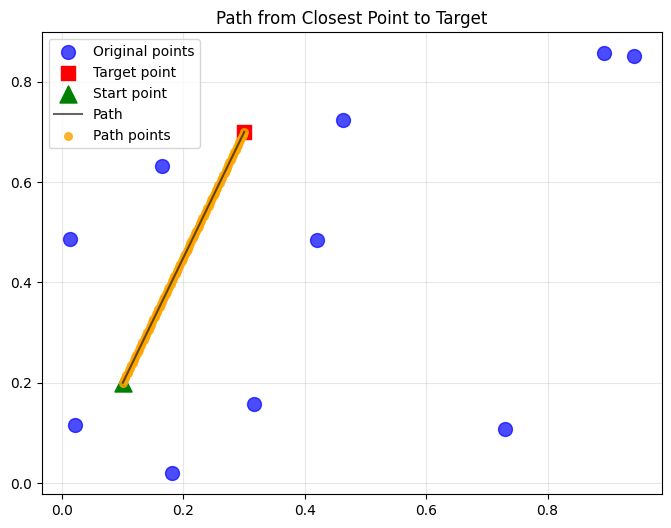

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Find the closest point in x to x1

start_point = np.array([0.1,0.2])

end_point = np.array([0.3,0.7]).reshape(1,-1)

# Create line of points from start_point to x1
n_points = 100
t = np.linspace(0, 1, n_points)  # Parameter from 0 to 1
x2 = start_point + t[:, np.newaxis] * (end_point[0] - start_point)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_train[:, 0], x_train[:, 1], c='blue', s=100, label='Original points', alpha=0.7)
plt.scatter(end_point[:, 0], end_point[:, 1], c='red', s=100, label='Target point', marker='s')
plt.scatter(start_point[0], start_point[1], c='green', s=150, label='Start point', marker='^')
plt.plot(x2[:, 0], x2[:, 1], 'k-', alpha=0.6, label='Path')
plt.scatter(x2[:, 0], x2[:, 1], c='orange', s=30, alpha=0.8, label='Path points')
plt.legend()
plt.title('Path from Closest Point to Target')
plt.grid(True, alpha=0.3)
plt.show()

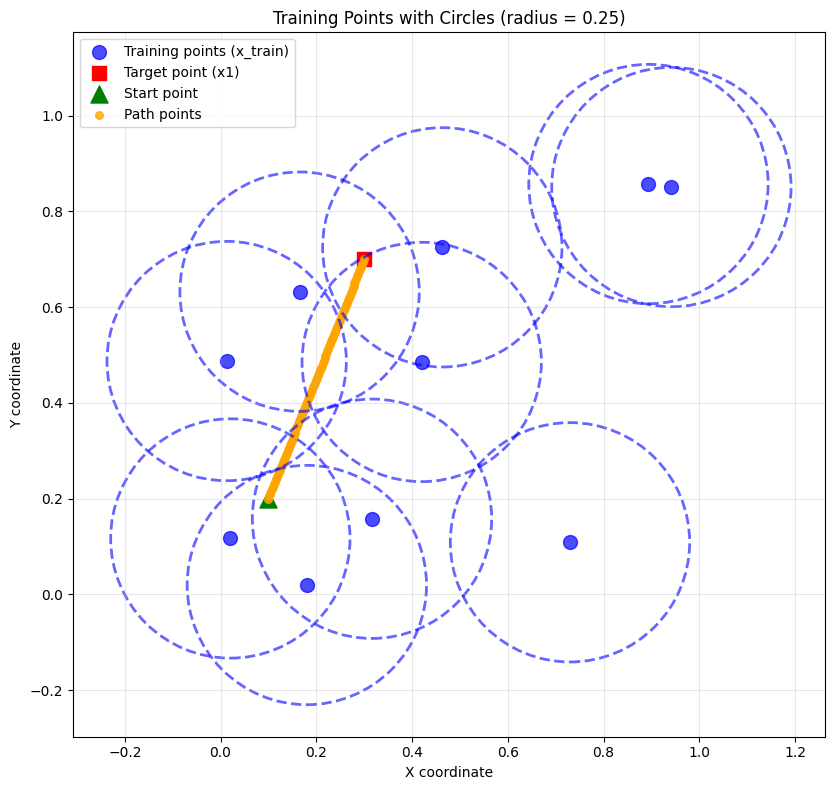

In [24]:
from matplotlib.patches import Circle

# Create plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot training points
ax.scatter(x_train[:, 0], x_train[:, 1], c='blue', s=100, label='Training points (x_train)', alpha=0.7)
ax.scatter(end_point[:, 0], end_point[:, 1], c='red', s=100, label='Target point (x1)', marker='s')
ax.scatter(start_point[0], start_point[1], c='green', s=150, label='Start point', marker='^')
ax.scatter(x2[:, 0], x2[:, 1], c='orange', s=30, alpha=0.8, label='Path points')

# Add circles around each training point
radius = 0.25
for i, point in enumerate(x_train):
    circle = Circle((point[0], point[1]), radius, fill=False, color='blue', 
                   linestyle='--', linewidth=2, alpha=0.6)
    ax.add_patch(circle)
    

# Set equal aspect ratio and limits
ax.set_aspect('equal')
# ax.set_xlim(-0.6, 1.6)
# ax.set_ylim(-0.6, 1.6)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title(f'Training Points with Circles (radius = {radius})')
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')

plt.tight_layout()
plt.show()

In [8]:
from gpcam.kernels import get_distance_matrix


def bump(d, r, beta, ampl):
    """
    Bump function for the kernel
    d: distances (can be any shape)
    r: radius parameter  
    ampl: amplitude
    """
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        #beta = 0.1
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values

    
def bump_kernel_geodesic(x1, x2, hps):

    d1 = get_distance_matrix(x1,x_train)
    d2 = get_distance_matrix(x2,x_train)
   
    # Compute bump functions
    # gs1: bump function values for x1 locations
    gs1 = bump(d1, hps[1], hps[2], 1.).T  # Shape: (n_train, len(x1))

    print(gs1.shape)
    # gs2: bump function values for x2 locations
    
    gs2 = bump(d2, hps[1], hps[2], 1.).T  # Shape: (n_train, len(x2))

    print(gs2.shape)
    # Compute kernel matrix: K[i,j] = sum over training points
    G = gs1.T @ gs2  # Shape: (len(x1), len(x2))
    
    # Scale by hyperparameters
    kernel_matrix = 2.0 * hps[0] * G / float(len(x_train))
    
    return kernel_matrix

(10, 1)
(10, 100)


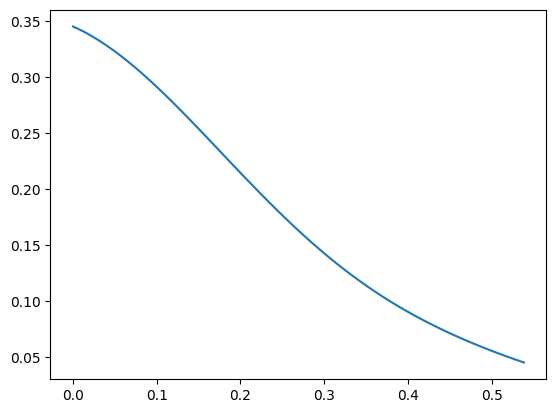

In [34]:
hps = [1,1,10]

#distances = np.linalg.norm(x1 - x2, axis=1)

d1 = get_distance_matrix(start_point.reshape(1,-1),x2)

my_kernel = bump_kernel_geodesic(start_point.reshape(1,-1),x2,hps)

plt.plot(d1.flatten(),my_kernel.flatten())

# OLD

In [53]:
# Step 2 (Fixed): Define the basic GP components

def find_indices_by_lookup_efficient(target_points, all_points, tolerance=1e-10):
    """
    More efficient and accurate point lookup using vectorized operations
    """
    from sklearn.neighbors import NearestNeighbors
    
    # Use k-d tree for fast nearest neighbor search
    nbrs = NearestNeighbors(n_neighbors=1, algorithm='kd_tree').fit(all_points)
    distances, indices = nbrs.kneighbors(target_points)
    
    # Check if matches are exact (within tolerance)
    exact_matches = distances.flatten() < tolerance
    if not np.all(exact_matches):
        print(f"Warning: {np.sum(~exact_matches)} points not exactly matched")
        print(f"Max distance to nearest neighbor: {np.max(distances):.6e}")
    
    return indices.flatten()
    

def bump(d, r, beta, ampl):
    """
    Bump function for the kernel
    d: distances (can be any shape)
    r: radius parameter  
    ampl: amplitude
    """
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        #beta = 0.1
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values

    
def bump_kernel_geodesic(x1, x2, hps):
        
     # Find indices of x1 and x2 in the full mesh
    x1_indices = find_indices_by_lookup_efficient(x1, vertices)
    x2_indices = find_indices_by_lookup_efficient(x2, vertices)
    
    # Extract geodesic distances from training points to x1 and x2 locations
    # d1: distances from training points to x1 locations
    d1 = all_geodesic_distances[np.ix_(indices_train, x1_indices)]  # Shape: (n_train, len(x1))
    
    # d2: distances from training points to x2 locations  
    d2 = all_geodesic_distances[np.ix_(indices_train, x2_indices)]  # Shape: (n_train, len(x2))
    
    # Compute bump functions
    # gs1: bump function values for x1 locations
    #gs1 = bump(d1, hps[1]/2., 1.)  # Shape: (n_train, len(x1))
    gs1 = bump(d1, hps[1], hps[2], 1.)  # Shape: (n_train, len(x1))
    
    # gs2: bump function values for x2 locations
    # gs2 = bump(d2, hps[1]/2., 1.)  # Shape: (n_train, len(x2))
    gs2 = bump(d2, hps[1], hps[2], 1.)  # Shape: (n_train, len(x2))
    
    # Compute kernel matrix: K[i,j] = sum over training points
    G = gs1.T @ gs2  # Shape: (len(x1), len(x2))
    
    # Scale by hyperparameters
    kernel_matrix = 2.0 * hps[0] * G / float(len(indices_train))
    
    return kernel_matrix


def my_mean(x, hps):
    return np.ones(len(x)) * hps[4]

def my_noise(x, hps):
    return np.ones(len(x)) * hps[3]


In [41]:
final_ll

np.float64(-12166.849899033854)

Kernel matrix shape: (1, 100)


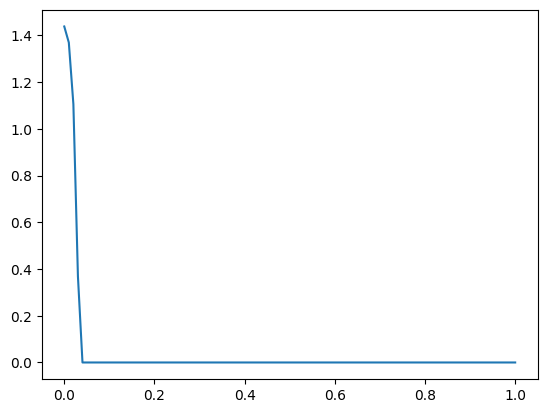

In [45]:
my_x1 = np.array([[0]])  # Shape: (1, 1) - 2D array
my_x2 = np.linspace(0, 1, 100).reshape(-1, 1)  # Shape: (100, 1) - 2D array

def bump_kernel_euclidean(x1, x2, hps):
    # Ensure inputs are 2D arrays
    if x1.ndim == 1:
        x1 = x1.reshape(-1, 1)
    if x2.ndim == 1:
        x2 = x2.reshape(-1, 1)
    
    d1 = get_distance_matrix(my_x1, x1)
    d2 = get_distance_matrix(my_x1, x2)
    
    # Compute bump functions
    gs1 = bump(d1, hps[1], hps[2], 1.)  # Shape: (len(my_x1), len(x1))
    gs2 = bump(d2, hps[1], hps[2], 1.)  # Shape: (len(my_x1), len(x2))
    
    # Compute kernel matrix
    G = gs1.T @ gs2  # Shape: (len(x1), len(x2))
    
    # Scale by hyperparameters
    kernel_matrix = 2.0 * hps[0] * G / float(len(my_x1))  # Fixed: use len(my_x1) not indices_train
    
    return kernel_matrix

# Test the function
result = bump_kernel_euclidean(my_x1, my_x2, final_hps)
print(f"Kernel matrix shape: {result.shape}")

plt.plot(my_x2.flatten(),result.flatten())

In [20]:
# Step 4: Configure hyperparameters and initialize GPOptimizer

# Define hyperparameter bounds
bounds = np.empty((5, 2))
bounds[0] = np.array([1e-3, 2])      # sigma_f: signal variance      
bounds[1] = np.array([1e-5, 0.1])    # length_scale: bump radius
bounds[2] = np.array([0.1, 1])        #  beta
bounds[3] = np.array([1e-10, 1e-9])   # sigma_n: noise variance
bounds[4] = np.array([-1, 1])        # mean: constant mean value

print("Hyperparameter bounds:")
print(f"  σ_f (signal variance):  [{bounds[0,0]:.1e}, {bounds[0,1]:.1f}]")
print(f"  length_scale (radius):   [{bounds[1,0]:.1e}, {bounds[1,1]:.1f}]") 
print(f"  σ_n (noise variance):    [{bounds[2,0]:.1e}, {bounds[2,1]:.1e}]")
print(f"  mean (constant):         [{bounds[3,0]:.1f}, {bounds[3,1]:.1f}]")

# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)
print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(x_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=bump_kernel_geodesic,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")


# Step 5: Train the GP model

my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='mcmc', max_iter=4000)


# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")


Hyperparameter bounds:
  σ_f (signal variance):  [1.0e-03, 2.0]
  length_scale (radius):   [1.0e-05, 0.1]
  σ_n (noise variance):    [1.0e-01, 1.0e+00]
  mean (constant):         [0.0, 0.0]

Initial hyperparameters: [1.0005e+00 5.0005e-02 5.5000e-01 5.5000e-10 0.0000e+00]
Initial log likelihood: -94303.018782
Final hyperparameters:   [ 7.19054839e-01  3.61882136e-02  5.80438517e-01  4.48637314e-10
 -1.06750503e-01]
Final log likelihood:    -12166.85


RMSE: 0.0007345848362748352 %


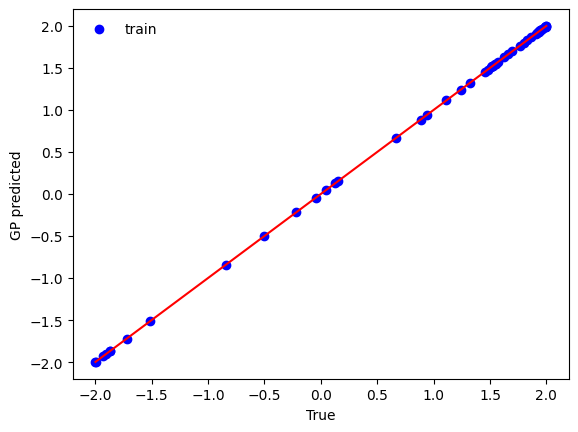

In [22]:
f_train = my_gpo.posterior_mean(x_train)["m(x)"]

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

print('RMSE:', my_gpo.rmse(x_train,y_train)*100/np.mean(y_train),'%')

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

RMSE: 1272.9140998479163 %


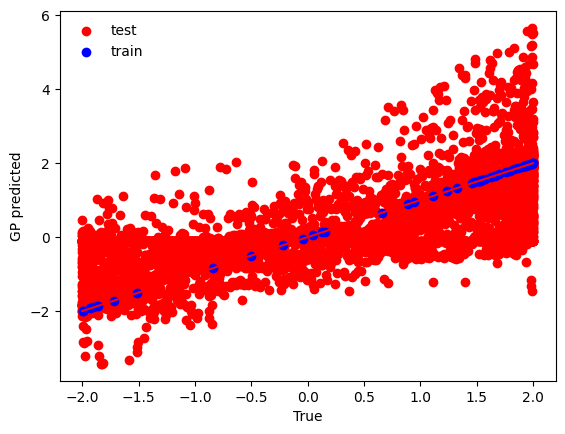

In [23]:
f = my_gpo.posterior_mean(x_test)["m(x)"]

print('RMSE:', my_gpo.rmse(x_test,y_test)*100/np.mean(y_test),'%')

my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_test,f,color="red",label = 'test')
plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

In [105]:
fig = go.Figure(data=[go.Scatter3d(
                            x=x_test[:,0],
                            y=x_test[:,1],
                            z=x_test[:,2], 
                            mode='markers', 
                            marker=dict(size=5, color=f, colorscale='plasma',opacity=0.8,
                                        cmin= np.min(y_test),
                                        cmax= np.max(y_test),
                                       showscale=True,  # This adds the colorbar
                                      colorbar=dict(thickness=15,
                                                    len=0.7)) 
                        )])

fig.update_layout(
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()

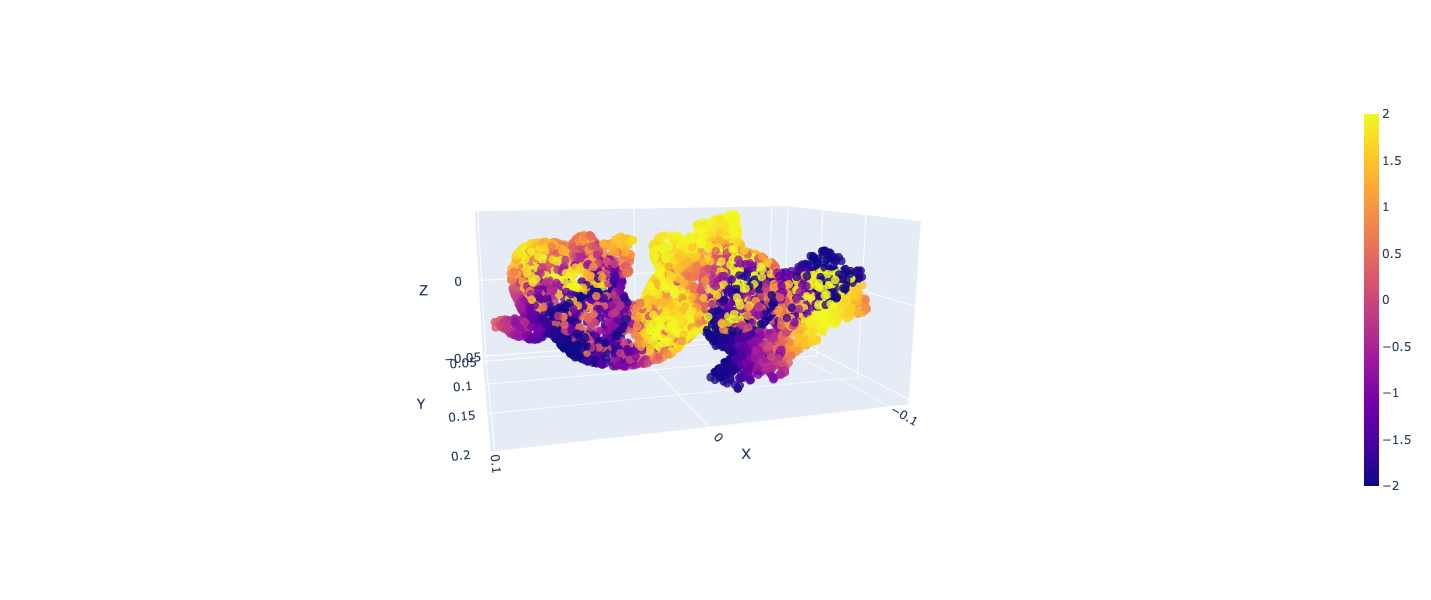

In [33]:
fig = go.Figure(data=[go.Scatter3d(
                            x=x_test[:,0],
                            y=x_test[:,1],
                            z=x_test[:,2], 
                            mode='markers', 
                            marker=dict(size=5, color=y_test, colorscale='plasma',opacity=0.8,
                                        cmin= np.min(y_test),
                                        cmax= np.max(y_test),
                                       showscale=True,  # This adds the colorbar
                                      colorbar=dict(thickness=15,
                                                    len=0.7)) 
                        )])

fig.update_layout(
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()

🔍 Creating variogram for training points
Training data shape: 51 points
Geodesic matrix shape: (51, 100179)
Training point pairs: 2550


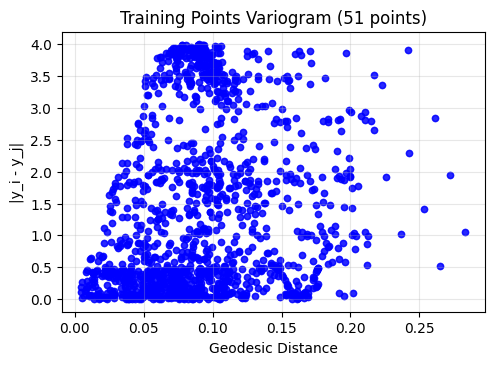

In [26]:
import matplotlib.pyplot as plt
import numpy as np

print("🔍 Creating variogram for training points")

# Current data structure:
# train_to_all_geodesics: (51, 100179) - distances from training points to all vertices
# indices_train: (51,) - vertex indices of training points  
# y_train: (51,) - ground truth values at training points

print(f"Training data shape: {len(y_train)} points")
print(f"Geodesic matrix shape: {train_to_all_geodesics.shape}")

# Method 1: Extract training point to training point distances
train_to_train_distances = train_to_all_geodesics[:, indices_train]  # Shape: (51, 51)

# Calculate pairwise differences in ground truth for training points
delta_y_train = np.abs(np.subtract.outer(y_train, y_train))

# Create variogram plot for training points
plt.figure(figsize=(12, 8))

# Plot 1: Training point variogram
plt.subplot(2, 2, 1)
# Remove diagonal (distance=0, difference=0)
mask = ~np.eye(len(y_train), dtype=bool)
plt.scatter(train_to_train_distances[mask], delta_y_train[mask], 
           alpha=0.6, s=20, color='blue')
plt.xlabel("Geodesic Distance")
plt.ylabel("|y_i - y_j|")
plt.title(f"Training Points Variogram ({len(y_train)} points)")
plt.grid(True, alpha=0.3)

print(f"Training point pairs: {mask.sum()}")

# old Code

In [ ]:
# All Points

fig = go.Figure(data=[go.Scatter3d(
                            x=vertices[:,0],
                            y=vertices[:,1],
                            z=vertices[:,2], 
                            mode='markers', 
                            marker=dict(size=5, color=ground_truth, colorscale='plasma',opacity=0.8,
                                       showscale=True,  # This adds the colorbar
                                      colorbar=dict(thickness=15,
                                                    len=0.7)) 
                        )])

fig.update_layout(
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()


# Computing Geodesics from Full Mesh

In [ ]:
# import torch
# import numpy as np
# import time
# import os
# import glob
# import re
# import networkx as nx

# # Check GPU availability
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Using device: {device}")
# if torch.cuda.is_available():
#     print(f"GPU: {torch.cuda.get_device_name()}")
#     print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# def compute_shortest_paths_batch_hybrid(nx_graph, source_vertices, n_vertices):
#     """
#     Compute shortest paths using NetworkX, return as numpy array
#     """
#     distances = np.full((len(source_vertices), n_vertices), np.inf, dtype=np.float32)
    
#     for idx, source in enumerate(source_vertices):
#         try:
#             # Compute shortest paths using NetworkX
#             distances_dict = nx.shortest_path_length(nx_graph, source=source, weight='weight')
            
#             # Fill the distance row
#             for target, dist in distances_dict.items():
#                 distances[idx, target] = dist
                
#         except Exception as e:
#             print(f"Error computing paths from vertex {source}: {e}")
#             # Keep infinity values for failed computations
    
#     return distances

# print("Computing FULL geodesic distance matrix with hybrid CPU/GPU approach...")
# print("Matrix stored on CPU, computations optimized with batching")

# n_vertices = len(vertices)
# print(f"Matrix size: {n_vertices} x {n_vertices}")
# print(f"Memory required: {n_vertices * n_vertices * 4 / 1e9:.1f} GB")

# # Checkpoint and final file patterns
# checkpoint_pattern = 'dragon_geodesic_matrix_checkpoint_vertex*.npz'
# final_file = 'dragon_geodesic_matrix_full.npy'

# def find_latest_checkpoint():
#     """Find the latest checkpoint file"""
#     checkpoint_files = glob.glob(checkpoint_pattern)
#     if not checkpoint_files:
#         return None, 0
    
#     latest_file = None
#     latest_vertex = -1
    
#     for file in checkpoint_files:
#         match = re.search(r'vertex(\d+)\.npz$', file)
#         if match:
#             vertex_num = int(match.group(1))
#             if vertex_num > latest_vertex:
#                 latest_vertex = vertex_num
#                 latest_file = file
    
#     return latest_file, latest_vertex

# def save_checkpoint_safe(vertex_num, matrix, start_time):
#     """Safely save checkpoint with unique filename"""
#     checkpoint_file = f'dragon_geodesic_matrix_checkpoint_vertex{vertex_num}.npz'
#     try:
#         np.savez_compressed(checkpoint_file, 
#                           matrix=matrix, 
#                           last_completed_vertex=vertex_num,
#                           total_vertices=n_vertices,
#                           start_time=start_time)
#         return checkpoint_file
#     except Exception as e:
#         print(f"❌ Error saving checkpoint: {e}")
#         return None

# def cleanup_old_checkpoints(keep_latest=1):
#     """Clean up old checkpoint files"""
#     checkpoint_files = glob.glob(checkpoint_pattern)
#     if len(checkpoint_files) <= keep_latest:
#         return
    
#     file_vertex_pairs = []
#     for file in checkpoint_files:
#         match = re.search(r'vertex(\d+)\.npz$', file)
#         if match:
#             vertex_num = int(match.group(1))
#             file_vertex_pairs.append((file, vertex_num))
    
#     file_vertex_pairs.sort(key=lambda x: x[1])
#     files_to_delete = file_vertex_pairs[:-keep_latest]
    
#     for file_to_delete, vertex_num in files_to_delete:
#         try:
#             os.remove(file_to_delete)
#             print(f"🗑️  Cleaned up old checkpoint: vertex {vertex_num}")
#         except:
#             pass

# # Check for existing checkpoint
# latest_checkpoint, latest_vertex = find_latest_checkpoint()
# start_vertex = 0

# if latest_checkpoint:
#     print(f"📁 Found latest checkpoint: {latest_checkpoint}")
#     try:
#         checkpoint_data = np.load(latest_checkpoint)
#         # Keep matrix on CPU
#         geo_dist_full = checkpoint_data['matrix']
#         start_vertex = int(checkpoint_data['last_completed_vertex']) + 1
#         print(f"🔄 Resuming from vertex {start_vertex}/{n_vertices}")
#         cleanup_old_checkpoints(keep_latest=2)
        
#     except Exception as e:
#         print(f"❌ Error loading checkpoint: {e}")
#         print("🆕 Starting fresh computation...")
#         geo_dist_full = np.full((n_vertices, n_vertices), np.inf, dtype=np.float32)
#         start_vertex = 0
# else:
#     print("🆕 No checkpoint found, starting fresh computation...")
#     print("📊 Allocating CPU memory for distance matrix...")
#     geo_dist_full = np.full((n_vertices, n_vertices), np.inf, dtype=np.float32)
#     print("✅ Memory allocated successfully")

# # Progress tracking
# start_time = time.time()
# save_interval = 2000  # Save every 2000 vertices
# batch_size = 200      # Smaller batches to be safe

# print(f"🚀 Starting computation with batch size {batch_size}")
# print("💡 Using NetworkX with optimized batching")

# for batch_start in range(start_vertex, n_vertices, batch_size):
#     batch_end = min(batch_start + batch_size, n_vertices)
#     current_batch_size = batch_end - batch_start
    
#     # Progress reporting
#     elapsed = time.time() - start_time
#     if batch_start > start_vertex:
#         vertices_processed = batch_start - start_vertex
#         if vertices_processed > 0:
#             est_total = elapsed * (n_vertices - start_vertex) / vertices_processed
#             remaining = est_total - elapsed
#             print(f"Vertices {batch_start:6d}-{batch_end-1:6d}/{n_vertices} "
#                   f"({batch_start/n_vertices*100:5.1f}%) - "
#                   f"Elapsed: {elapsed/60:5.1f}min - ETA: {remaining/60:5.1f}min")
#     else:
#         print(f"Starting batch {batch_start:6d}-{batch_end-1:6d}/{n_vertices}")
    
#     # Compute distances for current batch
#     try:
#         source_vertices = list(range(batch_start, batch_end))
        
#         # Compute shortest paths in batch
#         batch_distances = compute_shortest_paths_batch_hybrid(
#             full_mesh_graph, source_vertices, n_vertices)
        
#         # Update the full matrix (on CPU)
#         geo_dist_full[batch_start:batch_end] = batch_distances
        
#         # Optional: Clear any GPU memory if used
#         if torch.cuda.is_available():
#             torch.cuda.empty_cache()
        
#     except Exception as e:
#         print(f"❌ Error in batch {batch_start}-{batch_end}: {e}")
#         print("🔄 Falling back to single vertex computation...")
        
#         # Fallback: compute one by one
#         for i in range(batch_start, batch_end):
#             try:
#                 distances_from_i = nx.shortest_path_length(full_mesh_graph, source=i, weight='weight')
#                 for j, dist in distances_from_i.items():
#                     geo_dist_full[i, j] = dist
#             except Exception as single_error:
#                 print(f"❌ Error computing vertex {i}: {single_error}")
    
#     # Save checkpoint every save_interval vertices
#     if (batch_end - start_vertex) >= save_interval and (batch_end - start_vertex) % save_interval < batch_size:
#         print(f"💾 Saving checkpoint at vertex {batch_end-1}...")
#         saved_file = save_checkpoint_safe(batch_end-1, geo_dist_full, start_time)
#         if saved_file:
#             print(f"✅ Checkpoint saved: {saved_file}")
#             cleanup_old_checkpoints(keep_latest=3)
#         else:
#             print("❌ Failed to save checkpoint")

# # Final save
# total_time = time.time() - start_time
# print(f"✅ Full geodesic matrix computed in {total_time/60:.1f} minutes")
# print(f"Matrix shape: {geo_dist_full.shape}")
# print(f"Memory usage: {geo_dist_full.nbytes / (1024**3):.1f} GB")

# # Check for disconnected components
# n_inf = np.isinf(geo_dist_full).sum()
# print(f"Infinite distances: {n_inf}")
# if n_inf > 0:
#     print("⚠️  Some vertices are disconnected!")

# # Save the final matrix
# print("💾 Saving final geodesic matrix...")
# np.save(final_file, geo_dist_full)
# print(f"✅ Final matrix saved to '{final_file}'")

# # Clean up ALL checkpoint files after successful completion
# print("🗑️  Cleaning up all checkpoint files...")
# checkpoint_files = glob.glob(checkpoint_pattern)
# for checkpoint_file in checkpoint_files:
#     try:
#         os.remove(checkpoint_file)
#         print(f"🗑️  Removed: {checkpoint_file}")
#     except:
#         pass

# geo_dist_matrix = geo_dist_full

# print("🧹 Computation complete!")

In [ ]:
# Load the computed geodesic distance matrix
print("📁 Loading geodesic distance matrix from file...")
geo_dist_matrix = np.load('dragon_geodesic_matrix_full.npy')

print(f"✅ Loaded matrix with shape: {geo_dist_matrix.shape}")


In [ ]:
# def validate_distance_matrix(geo_dist_matrix):
#     """
#     Validate basic mathematical properties of distance matrix
#     """
#     print("🔍 Validating geodesic distance matrix...")
#     n = geo_dist_matrix.shape[0]
    
#     # Check 1: Square matrix
#     assert geo_dist_matrix.shape[0] == geo_dist_matrix.shape[1], "Matrix not square!"
#     print(f"✅ Matrix is square: {n} x {n}")
    
#     # Check 2: Diagonal should be zero
#     diagonal_max = np.max(np.diag(geo_dist_matrix))
#     diagonal_min = np.min(np.diag(geo_dist_matrix))
#     print(f"✅ Diagonal range: [{diagonal_min:.6f}, {diagonal_max:.6f}] (should be ~0)")
#     assert diagonal_max < 1e-6, f"Diagonal not zero! Max = {diagonal_max}"
    
#     # Check 3: Non-negative distances
#     min_dist = np.min(geo_dist_matrix)
#     print(f"✅ Minimum distance: {min_dist:.6f} (should be ≥ 0)")
#     assert min_dist >= 0, f"Negative distances found! Min = {min_dist}"
    
#     # Check 4: Symmetry
#     max_asymmetry = np.max(np.abs(geo_dist_matrix - geo_dist_matrix.T))
#     print(f"✅ Max asymmetry: {max_asymmetry:.6f} (should be ~0)")
#     assert max_asymmetry < 1e-5, f"Matrix not symmetric! Max asymmetry = {max_asymmetry}"
    
#     # Check 5: Triangle inequality (sample check)
#     print("🔍 Checking triangle inequality (sampling 1000 triplets)...")
#     violations = 0
#     for _ in range(1000):
#         i, j, k = np.random.choice(n, 3, replace=False)
#         if geo_dist_matrix[i,j] + geo_dist_matrix[j,k] < geo_dist_matrix[i,k] - 1e-6:
#             violations += 1
#     print(f"✅ Triangle inequality violations: {violations}/1000 (should be 0)")
    
#     # Check 6: Connectivity
#     n_infinite = np.sum(np.isinf(geo_dist_matrix))
#     n_disconnected = n_infinite - n  # Subtract diagonal
#     print(f"✅ Disconnected pairs: {n_disconnected} (should be 0 for connected mesh)")
    
#     # Check 7: Distance distribution
#     finite_distances = geo_dist_matrix[np.isfinite(geo_dist_matrix) & (geo_dist_matrix > 0)]
#     print(f"✅ Distance statistics:")
#     print(f"   Min: {np.min(finite_distances):.6f}")
#     print(f"   Max: {np.max(finite_distances):.6f}")
#     print(f"   Mean: {np.mean(finite_distances):.6f}")
#     print(f"   Std: {np.std(finite_distances):.6f}")
    
#     return True

# # Run validation
# validate_distance_matrix(geo_dist_matrix)

In [ ]:
def find_and_plot_actual_geodesic_path(start_idx, end_idx, vertices, mesh_graph, ground_truth=None):
    """
    Find and plot actual geodesic path using NetworkX shortest path
    """
    print(f"🔍 Finding actual geodesic path from vertex {start_idx} to {end_idx}...")
    
    try:
        # Find shortest path using NetworkX
        path = nx.shortest_path(mesh_graph, source=start_idx, target=end_idx, weight='weight')
        path_length = nx.shortest_path_length(mesh_graph, source=start_idx, target=end_idx, weight='weight')
        
        #print(f"✅ Path found: {len(path)} vertices, geodesic length = {path_length:.6f}")
        
        # Get path coordinates
        path_coords = vertices[path]
        
        # Create the plot
        fig = go.Figure()
        
        # 1. Background dragon mesh
        fig.add_trace(go.Scatter3d(
            x=vertices[:,0], 
            y=vertices[:,1], 
            z=vertices[:,2], 
            mode='markers', 
            marker=dict(
                size=3, 
                color=ground_truth if ground_truth is not None else 'lightgray',
                colorscale='plasma' if ground_truth is not None else None,
                opacity=0.3,
                showscale=True,  # This adds the colorbar
                colorbar=dict(thickness=15,
                                len=0.7
            )
            ),
            name='Dragon Mesh',
            showlegend=True
        ))
        
        # 2. Geodesic path as connected line
        fig.add_trace(go.Scatter3d(
            x=path_coords[:,0], 
            y=path_coords[:,1], 
            z=path_coords[:,2], 
            mode='lines+markers',
            line=dict(color='red', width=10),
            marker=dict(size=6, color='red'),
            name=f'Geodesic Path ({len(path)} vertices)',
            showlegend=True
        ))
        
        # 3. Start point (large green diamond)
        fig.add_trace(go.Scatter3d(
            x=[vertices[start_idx,0]], 
            y=[vertices[start_idx,1]], 
            z=[vertices[start_idx,2]], 
            mode='markers',
            marker=dict(size=20, color='green', symbol='diamond'),
            name=f'Start (vertex {start_idx})',
            showlegend=True
        ))
        
        # 4. End point (large blue diamond)  
        fig.add_trace(go.Scatter3d(
            x=[vertices[end_idx,0]], 
            y=[vertices[end_idx,1]], 
            z=[vertices[end_idx,2]], 
            mode='markers',
            marker=dict(size=20, color='blue', symbol='diamond'),
            name=f'End (vertex {end_idx})',
            showlegend=True
        ))
        
        # Calculate metrics
        euclidean_length = np.linalg.norm(vertices[end_idx] - vertices[start_idx])
        matrix_distance = geo_dist_matrix[start_idx, end_idx]
        
        # Layout
        fig.update_layout(
            #title=f'Geodesic Path: Vertex {start_idx} → {end_idx}<br>' +
             #     f'NetworkX: {path_length:.6f} | Matrix: {matrix_distance:.6f} | Euclidean: {euclidean_length:.6f}',
            scene=dict(
                xaxis_title='X', 
                yaxis_title='Y', 
                zaxis_title='Z',
                camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
            ),
            width=900, 
            height=700, 
            margin=dict(r=30, b=20, l=20, t=20)
        )


        #fig.write_image("dragon.pdf")
        #fig.write_image("my_plot.pdf", engine="orca")
        fig.write_html("dragon_with_geodesics.html")

        
        fig.show()
        
        # Verification
        print(f"📊 Path verification:")
        print(f"   NetworkX path length: {path_length:.6f}")
        print(f"   Matrix distance:      {matrix_distance:.6f}")
        print(f"   Difference:           {abs(path_length - matrix_distance):.8f}")
        print(f"   Euclidean distance:   {euclidean_length:.6f}")
        print(f"   Geodesic/Euclidean:   {path_length/euclidean_length:.3f}x")
        
        return path, path_length
        
    except nx.NetworkXNoPath:
        print(f"❌ No path exists between vertices {start_idx} and {end_idx}")
        return None, None
    except Exception as e:
        print(f"❌ Error finding path: {e}")
        return None, None

# Test a variety of paths
test_paths = [
    #(1000, 2000),   # Short nearby path
    #(1000, 10000),  # Medium path
    #(10000, 50000), # Long path across sections
    (100, 90000),  # Very long path end-to-end
    #(7, 50000),     # From snout (ground truth source) to far point
]

for start, end in test_paths:
    print(f"\n{'='*50}")
    print(f"Testing path: {start} → {end}")
    path, length = find_and_plot_actual_geodesic_path(start, end, vertices, full_mesh_graph, ground_truth)
    
    if path:
        print(f"✅ Success! Path has {len(path)} vertices")
    else:
        print(f"❌ Failed to find path")

# Computing the Variogram on subset of data

In [ ]:
# indices_orig_train = np.array([3316, 10960, 24947, 33498, 33513, 34844, 35740, 35830, 36026,
#          36654, 36727, 37597, 39066, 39886, 40050, 41165, 41387, 41430,
#          42420, 43012, 43383, 45296, 45796, 47431, 48346, 48779, 49033,
#          49127, 50374, 50878, 51132, 51168, 51175, 55643, 55863,
#          56414, 56568, 56933, 57130, 57168, 57536, 60028, 61432, 61915,
#          62936, 63657, 64280, 64542, 75551, 87643, 95423])

# Step 1: Randomly sample 100 points for training (instead of manual definition)
np.random.seed(42)  # For reproducibility
n_train_points = 200
indices_orig_train = np.random.choice(len(vertices), size=n_train_points, replace=False)



total_points = 3000

# Step 2: Take additional random points (excluding the training points)
np.random.seed(42)
available_indices = np.setdiff1d(np.arange(len(vertices)), indices_orig_train)
additional_indices = np.random.choice(available_indices, size=total_points-len(indices_orig_train), replace=False)

# Step 3: Combine to get 1000 total points
subset_indices = np.concatenate([indices_orig_train, additional_indices])

X = vertices[subset_indices]
y = ground_truth[subset_indices]

print("X shape:", X.shape)  # (1000, 3)
print("y shape:", y.shape)  # (1000,)

# Create train and test indices for the subset
n_train = len(indices_orig_train)
indices_train = np.arange(n_train)                    # [0, 1, 2, ..., 50]
indices_test = np.arange(n_train, total_points)       # [51, 52, 53, ..., 999]

# Extract training and test data using indices
x_train = X[indices_train]        # Training coordinates
y_train = y[indices_train]        # Training values
x_test = X[indices_test]          # Test coordinates  
y_test = y[indices_test]          # Test values

print("indices_train:", indices_train.shape, "range:", indices_train[0], "to", indices_train[-1])
print("indices_test:", indices_test.shape, "range:", indices_test[0], "to", indices_test[-1])
print("x_train shape: ", x_train.shape)  # (51, 3)
print("y_train shape: ", y_train.shape)  # (51,)
print("x_test shape: ", x_test.shape)    # (949, 3)
print("y_test shape: ", y_test.shape)    # (949,)
print("Total: ", x_train.shape[0] + x_test.shape[0])  # total_points

In [ ]:
snout_vertex = 7

# Full visualization with visible training points
fig = go.Figure(data=[
    # Original scatter plot (you can uncomment this)
    go.Scatter3d(
        x=X[:,0], y=X[:,1], z=X[:,2], 
        mode='markers', 
        marker=dict(
            size=5, 
            color=y, 
            colorscale='plasma', 
            opacity=0.8,
            showscale=True,  # This adds the colorbar
            colorbar=dict(
                thickness=15,
                len=0.7
            )
        ),
        name='Ground Truth'
    ),
    # Red point for snout vertex
    go.Scatter3d(
        x=[vertices[snout_vertex, 0]], 
        y=[vertices[snout_vertex, 1]], 
        z=[vertices[snout_vertex, 2]],
        mode='markers',
        marker=dict(size=25, color='red'),
        name='Snout Vertex'
    ),
    # Black training points - LARGE with white outline for visibility
    go.Scatter3d(
        x=X[indices_train, 0], 
        y=X[indices_train, 1], 
        z=X[indices_train, 2],
        mode='markers',
        marker=dict(
            size=10, 
            color='black', 
            line=dict(width=3, color='white'),  # White outline makes them pop
            symbol='diamond'
        ),
        name='Training Points (51)'
    )
])

fig.update_layout(
    scene=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
    ),
    width=600, height=600, 
    margin=dict(r=30, b=20, l=20, t=20)
)
fig.show()

In [ ]:
# Sampled points, shape: (N, 3)
fig = go.Figure(data=[go.Scatter3d(
    x=x_train[:,0],y=x_train[:,1],z=x_train[:,2], mode='markers', marker=dict( size=5, color=y_train, colorscale='plasma',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()


In [ ]:
# Extract geodesic distances for your subset
print("🔍 Creating variogram for the subset of data")

# Get the geodesic distance submatrix for your subset indices
geo_dist_subset = geo_dist_matrix[np.ix_(subset_indices, subset_indices)]

# Calculate pairwise differences in ground truth for subset
my_delta_y_subset = np.abs(np.subtract.outer(y, y))

# Plot subset variogram
plt.figure(figsize=(10, 6))
plt.scatter(geo_dist_subset.flatten(), my_delta_y_subset.flatten(), alpha=0.1, s=1)
plt.xlabel("Geodesic Distances")
plt.ylabel("Absolute Difference in Ground Truth (|y_i - y_j|)")
plt.title(f"Variogram - Subset Data ({total_points} points)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Subset variogram: {len(geo_dist_subset.flatten())} point pairs")

In [ ]:
# Variogram for training data only
print("🔍 Creating variogram for training data...")

# Get geodesic distances for training points
train_global_indices = subset_indices[indices_train]  # Convert back to global indices
geo_dist_train = geo_dist_matrix[np.ix_(train_global_indices, train_global_indices)]

# Calculate pairwise differences for training data
my_delta_y_train = np.abs(np.subtract.outer(y_train, y_train))

plt.figure(figsize=(10, 6))
plt.scatter(geo_dist_train.flatten(), my_delta_y_train.flatten(), alpha=0.7, s=20, color='red')
plt.xlabel("Geodesic Distances")
plt.ylabel("Absolute Difference in Ground Truth (|y_i - y_j|)")
plt.title(f"Variogram - Training Data Only ({len(indices_train)} points)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Training variogram: {len(geo_dist_train.flatten())} point pairs")

In [ ]:
# # Compute the half squared difference matrix
# my_delta_y2 = 0.5 * (np.subtract.outer(y, y)) ** 2

# # Plot the classical semi-variogram
# plt.scatter(geo_dist_matrix_latent_space.flatten(), my_delta_y2.flatten(), alpha=0.3, s=4)
# plt.xlabel('Geodesic distance (latent space)')
# plt.ylabel(r'$\frac{1}{2}(f(x_i) - f(x_j))^2$')
# plt.title('Empirical semi-variogram')
# plt.show()

# GP Model

In [ ]:
#Noise Function
def my_noise(x,hps):
    my_s = np.ones(len(x))*hps[2]
    #noise = np.diag(my_s)
    return my_s

# Mean Function
def my_mean(x,hps):
    mean = np.ones(len(x))*hps[3]
    return mean

In [ ]:
def find_indices_ordered(x, x_data):
    matches = (x[:, None, :] == x_data[None, :, :]).all(axis=2)
    
    # Check if all points were found
    found = matches.any(axis=0)
    if not found.all():
        raise ValueError(f"Some points in x_data not found in x")
    
    indices_temp = np.argmax(matches, axis=0)
    return indices_temp


def bump(d, r, ampl):
    """
    evaluates the bump function
    x ... a point (1d numpy array)
    x0 ... 1d numpy array of location of bump function
    returns the bump function b(x,x0) with radius r
    """
    #x_new = x - x0
    #d = np.linalg.norm(x_new, axis = 1)
    a = np.zeros(d.shape)
    a = 1.0 - (d**2/r**2)
    i = np.where(a > 0.0)
    bump = np.zeros(a.shape)
    beta = 0.1
    e = np.exp((-beta/a[i])+beta)
    bump[i] = ampl * e
    return bump

# Precompute x_data_indices once (outside the kernel function)
x_data_indices_global = find_indices_ordered(X, x_train)

def bump_kernel_geodesic_fast(x1, x2, hps):
    """Fast version of bump kernel"""
    # Find indices for x_data in X
    x1_indices = find_indices_ordered(X, x1)
    x2_indices = find_indices_ordered(X, x2)

    # Get geodesic distances (Use precomputed indices)
    d1 = geo_dist_matrix[np.ix_(x1_indices, x_data_indices_global)]
    d2 = geo_dist_matrix[np.ix_(x2_indices, x_data_indices_global)]
    
    # Compute bump functions
    gs1 = bump(d1, hps[1]/2., 1.).T
    gs2 = bump(d2, hps[1]/2., 1.).T
    
    G = gs1.T @ gs2
    return 2.0 * hps[0] * G/float(len(x_train))

In [ ]:
# Defining the bounds of hyperparameter optimization
bounds = np.empty((4,2))
# Kernel Sq Exp 
bounds[0] = np.array([1e-3,1])   # signal variance      
bounds[1] = np.array([1e-3,0.1])   # kernel length for all input dimensions
# Noise
bounds[2] = np.array([1e-6,1e-5]) 
# Mean
bounds[3] = np.array([-1,1]) #np.min(y_train),np.max(y_train)])

init_hps = np.mean(bounds,axis=1)

my_gpo = GPOptimizer(x_train,y_train,
                     init_hyperparameters = init_hps,
                     kernel_function = bump_kernel_geodesic_fast,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                     )

my_gpo.train(hyperparameter_bounds = bounds, init_hyperparameters = init_hps, method='mcmc', max_iter = 4000)

print("GP Training Complete!")

my_gpo.get_hyperparameters()

In [ ]:
f_train = my_gpo.posterior_mean(x_train)["m(x)"]

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

In [ ]:

f = my_gpo.posterior_mean(x_test)["m(x)"]

print('RMSE:', my_gpo.rmse(x_test,y_test)*100/np.mean(y_test),'%')

my_line = np.linspace(np.min(y_test),np.max(y_train),10)


plt.scatter(y_test,f,color="red",label = 'test')
plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()